In [ ]:
# NUMPY imports 
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
 
# Scikit-learn datasets & model selection
from sklearn.datasets import (make_classification, make_regression,
load_breast_cancer, load_diabetes)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
 
# Classification model_collection
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
 
# Regression model_collection
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
 
# Evaluation metrics — THE CORE OF THIS NOTEBOOK
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve,
    confusion_matrix, classification_report,
    mean_squared_error, mean_absolute_error, r2_score,
    ConfusionMatrixDisplay
)

In [ ]:


# Plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
np.random.seed(42)
print("All libraries loaded successfully!")
print(f"NumPy: {np.__version__} | Pandas: {pd.__version__}")
 

In [ ]:
#Dataset prediction

#classification: breast dataset_classification dataset 
dataset_classification = load_breast_cancer()
X_clf, y_clf = dataset_classification.data, dataset_classification.target # 0=malignant , 1= benign
X_train_c, X_test_c, y_train_c,y_test_c= train_test_split(X_clf, y_clf,
test_size=0.2, random_state=42)

#featuring scaling - important for logistic regression and SVM
classifier_scaler = StandardScaler()
X_train_c = classifier_scaler.fit_transform(X_train_c)
X_test_c = classifier_scaler.transform(X_test_c)

#Diabetic dataset
dataset_regression = load_diabetes()
X_reg, y_reg = dataset_regression.data, dataset_regression.target

X_train_r, X_test_r, y_train_r, y_test_r, = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

regression_scaler = StandardScaler()
X_train_r = regression_scaler.fit_transform(X_train_r)
X_test_r = regression_scaler.transform(X_test_r)

#quick summery
print("CLASSIFICATION DATASER (Breast Cancer)")
print(f"  Train: {X_train_c.shape} | Test: {X_test_c.shape}")
print(f"  Class balance — Malignant: {(y_clf==0).sum()} | Benign: {(y_clf==1).sum()}\n")
print("REGRESSION DATASET (Diabetes)")
print(f"  Train: {X_train_r.shape} | Test: {X_test_r.shape}")
print(f"  Target range: [{y_reg.min():.0f}, {y_reg.max():.0f}]")
 

CLASSIFICATION DATASER (Breast Cancer)
  Train: (455, 30) | Test: (114, 30)
  Class balance — Malignant: 212 | Benign: 357

REGRESSION DATASET (Diabetes)
  Train: (353, 10) | Test: (89, 10)
  Target range: [25, 346]


Feature names: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness']
Class imbalance ratio: 0.59


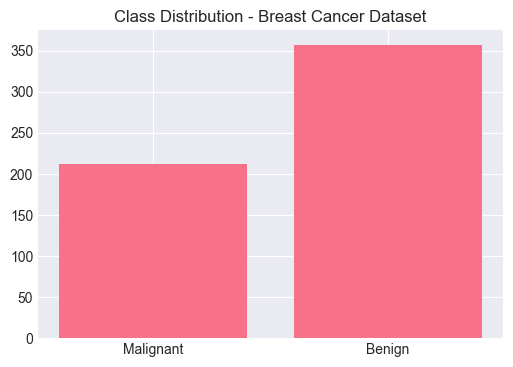

In [ ]:
#Task 
#1. print the feature names of the breast dataset_classification dataset
#2. calculate and print class imbalance ratio(malignant/benign)
#3. plot a bar chart showing class distribuiton

# Print first 5 feature names
print("Feature names:", dataset_classification.feature_names[:5])


# Calculate imbalance ratio
# 0 = malignant, 1 = benign
malignant = (dataset_classification.target == 0).sum()
benign = (dataset_classification.target == 1).sum()

imbalance_ratio = malignant / benign

print(f"Class imbalance ratio: {imbalance_ratio:.2f}")


# Plot class distribution
plt.figure(figsize=(6, 4))

labels = ["Malignant", "Benign"]
counts = [malignant, benign]

plt.bar(labels, counts)



plt.title("Class Distribution - Breast Cancer Dataset")
plt.show()


logistic Regression: Accuracy = 0.9737
Random Forest: Accuracy = 0.9649
Gradient Boosting: Accuracy = 0.9561


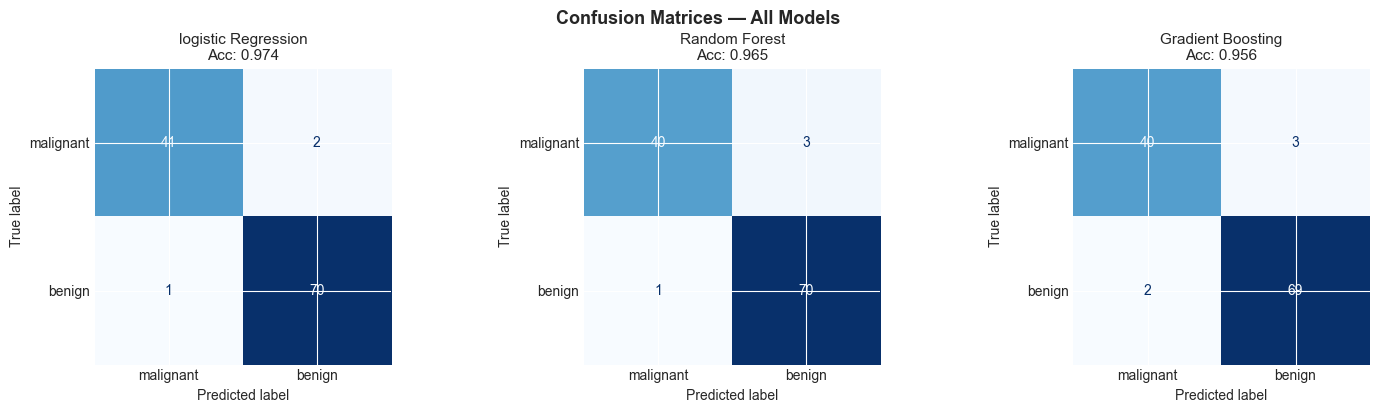

In [11]:
#Accuracy and confusion matrix 
model_collection = {
    'logistic Regression' : LogisticRegression(max_iter=1000),
    'Random Forest' : RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting' : GradientBoostingClassifier(n_estimators=100, random_state=42)
}

evaluation_results = {}
     
for name, model in model_collection.items():
    model.fit(X_train_c, y_train_c)
    y_pred = model.predict(X_test_c)
    y_proba = model.predict_proba(X_test_c)[:,1]

    evaluation_results[name] = {
        'model':model,
        'y_pred' : y_pred,
        'y_proba' : y_proba,
        'accuracy': accuracy_score(y_test_c,y_pred),
        'confusion_matrix_data' : confusion_matrix(y_test_c , y_pred)
    }
    print(f"{name}: Accuracy = {evaluation_results[name]['accuracy']:.4f}")
 
# ── Visualise confusion matrices side by side ──
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
 
for ax, (name, res) in zip(axes, evaluation_results.items()):
    disp = ConfusionMatrixDisplay(
        confusion_matrix=res['confusion_matrix_data'],
        display_labels=dataset_classification.target_names
    )
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{name}\nAcc: {res['accuracy']:.3f}", fontsize=11)
 
plt.tight_layout()
plt.suptitle("Confusion Matrices — All Models", y=1.02, fontsize=13, fontweight='bold')
plt.show()

In [ ]:
#Task
#Confusion Matrix Deep Dive 
# # Instructions:
# 1. Pick the Logistic Regression model's confusion matrix
# 2. Extract TP, FP, TN, FN values manually
# 3. Calculate accuracy from scratch (without sklearn) and verify it matches Recall: sklearn's confusion_matrix returns:#   [[TN, FP],#    [FN, TP]]
 
 
# 1. Get confusion matrix
confusion_matrix_data = confusion_matrix(y_test_c, y_pred)
print("Confusion Matrix:\n", confusion_matrix_data)

# 2. Extract values
TN = confusion_matrix_data[0][0]
FP = confusion_matrix_data[0][1]
FN = confusion_matrix_data[1][0]
TP = confusion_matrix_data[1][1]

print("\nExtracted Values:")
print("TN:", TN)
print("FP:", FP)
print("FN:", FN)
print("TP:", TP)

# 3. Calculate accuracy manually
accuracy_manual = (TP + TN) / (TP + TN + FP + FN)
print(f"\nManual Accuracy: {accuracy_manual:.4f}")

# Verify with sklearn
accuracy_sklearn = accuracy_score(y_test_c, y_pred)
print(f"Sklearn Accuracy: {accuracy_sklearn:.4f}")

Confusion Matrix:
 [[40  3]
 [ 2 69]]

Extracted Values:
TN: 40
FP: 3
FN: 2
TP: 69

Manual Accuracy: 0.9561
Sklearn Accuracy: 0.9561
